In [3]:
from google.colab import files
uploaded = files.upload()

Saving dim_dates_cleaned.csv to dim_dates_cleaned (1).csv
Saving dim_state_cleaned.csv to dim_state_cleaned (1).csv
Saving fact_disease_surveillance_cleaned.csv to fact_disease_surveillance_cleaned (1).csv
Saving fact_lab_healthcare_cleaned.csv to fact_lab_healthcare_cleaned (1).csv


In [4]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib.ticker import FuncFormatter

In [5]:
fact_lab_healthcare = pd.read_csv("fact_lab_healthcare_cleaned.csv")
dim_state = pd.read_csv("dim_state_cleaned.csv")
dim_dates = pd.read_csv("dim_dates_cleaned.csv")
fact_disease_surveillance = pd.read_csv("fact_disease_surveillance_cleaned.csv")

print("All datasets loaded successfully!")

print("\nLab Healthcare:")
print(fact_lab_healthcare.head())

print("\nState:")
print(dim_state.head())

print("\nDates:")
print(dim_dates.head())

print("\nDisease Surveillance:")
print(fact_disease_surveillance.head())

All datasets loaded successfully!

Lab Healthcare:
   fact_id  date_id  state_id  total_tests  positive_tests  positivity_rate  \
0        1        1         1      22918.0          4084.0            17.82   
1        2        1         2       1323.0            64.0             4.85   
2        3        1         3      28315.0          1734.5            14.68   
3        4        1         4      90239.0          8653.0             9.59   
4        5        1         5      23747.0          3931.0            16.56   

   vaccination_coverage_pct  booster_coverage_pct  hospital_beds  doctors  \
0                      76.8                  51.4        12451.0     1793   
1                      91.6                  51.6          465.0       65   
2                      71.1                  37.2         8002.0     2955   
3                      79.8                  26.1        10373.0     4215   
4                      90.0                  52.3         7966.0      760   

   phc_coun

In [6]:
# Load datasets

fact_lab_healthcare = pd.read_csv("fact_lab_healthcare_cleaned.csv")
dim_state = pd.read_csv("dim_state_cleaned.csv")
dim_dates = pd.read_csv("dim_dates_cleaned.csv")
fact_disease_surveillance = pd.read_csv("fact_disease_surveillance_cleaned.csv")

print("All datasets loaded successfully!")

All datasets loaded successfully!


In [7]:
#Check the datasets
print("fact_lab_healthcare:", fact_lab_healthcare.shape)
print("dim_state:", dim_state.shape)
print("dim_dates:", dim_dates.shape)
print("fact_disease_surveillance:", fact_disease_surveillance.shape)

fact_lab_healthcare: (1152, 17)
dim_state: (32, 7)
dim_dates: (36, 7)
fact_disease_surveillance: (13824, 18)


In [8]:
# Style for plots
plt.style.use("ggplot")
# Format large numbers as K / M
def format_units(x, pos):
    if x >= 1_000_000:
        return f"{x / 1_000_000:.1f}M"
    elif x >= 1_000:
        return f"{x / 1_000:.0f}K"
    else:
        return f"{x:.0f}"

In [9]:
# 1. Total Tests Conducted Overall
total_tests = fact_lab_healthcare["total_tests"].sum()
print(f"Total Tests Conducted: {total_tests:,.0f}")

Total Tests Conducted: 40,313,461


In [10]:
# Merge healthcare data with state dimension
health_state = fact_lab_healthcare.merge(
    dim_state,
    on="state_id",
    how="left"
)
# Calculate total tests by state
state_tests = (
    health_state
    .groupby("state_name")["total_tests"]
    .sum()
    .sort_values(ascending=False)
)
print(state_tests)

state_name
Uttar Pradesh        6607419.0
Maharashtra          3641292.0
Bihar                3566296.0
West Bengal          2887117.0
Madhya Pradesh       2478991.0
Rajasthan            2440857.0
Tamil Nadu           2317280.0
Gujarat              2139049.0
Karnataka            1793676.0
Andhra Pradesh       1514322.0
Odisha               1325477.0
Jharkhand            1138787.0
Kerala               1111392.0
Telangana            1078770.0
Assam                 964691.0
Delhi (NCT)           911388.0
Punjab                894234.0
Chhattisgarh          866741.0
Haryana               829884.0
Uttarakhand           569083.0
Jammu and Kashmir     380790.0
Himachal Pradesh      232241.0
Tripura               125933.0
Meghalaya              96937.0
Manipur                92661.0
Nagaland               63637.0
Goa                    46456.0
Sikkim                 44172.0
Arunachal Pradesh      43290.0
Puducherry             42573.0
Mizoram                35944.0
Ladakh                 32081

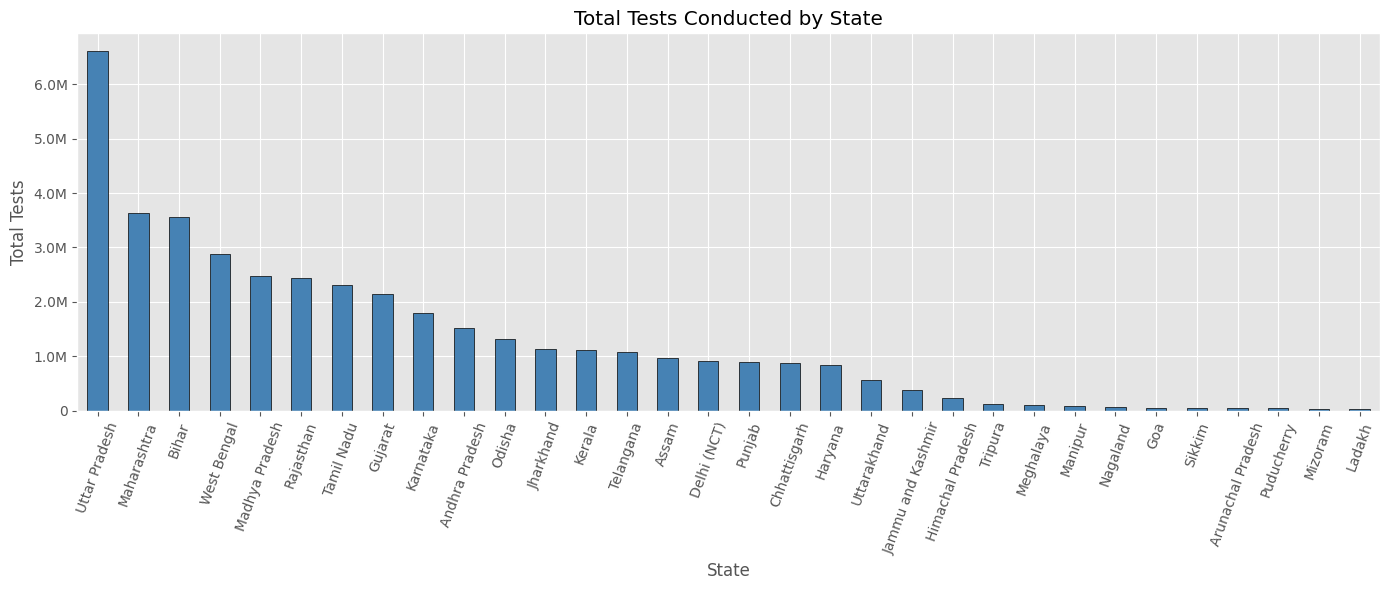

In [11]:
# Visualization: Total Tests by State
plt.figure(figsize=(14, 6))

state_tests.plot(
    kind="bar",
    color="steelblue",
    edgecolor="black"
)
plt.title("Total Tests Conducted by State")
plt.xlabel("State")
plt.ylabel("Total Tests")
plt.xticks(rotation=70)
# Format Y-axis as K / M
plt.gca().yaxis.set_major_formatter(
    FuncFormatter(format_units)
)
plt.tight_layout()
plt.show()

In [12]:
# 2. Overall Test Positivity Rate
overall_rate = (
    fact_lab_healthcare["positive_tests"].sum()
    / fact_lab_healthcare["total_tests"].sum()
) * 100
print(f"Overall Positivity Rate: {overall_rate:.2f}%")

Overall Positivity Rate: 9.86%


In [13]:
# Merge healthcare data with date dimension
health_date = fact_lab_healthcare.merge(
    dim_dates,
    on="date_id",
    how="left"
)
print(health_date.head())

   fact_id  date_id  state_id  total_tests  positive_tests  positivity_rate  \
0        1        1         1      22918.0          4084.0            17.82   
1        2        1         2       1323.0            64.0             4.85   
2        3        1         3      28315.0          1734.5            14.68   
3        4        1         4      90239.0          8653.0             9.59   
4        5        1         5      23747.0          3931.0            16.56   

   vaccination_coverage_pct  booster_coverage_pct  hospital_beds  doctors  \
0                      76.8                  51.4        12451.0     1793   
1                      91.6                  51.6          465.0       65   
2                      71.1                  37.2         8002.0     2955   
3                      79.8                  26.1        10373.0     4215   
4                      90.0                  52.3         7966.0      760   

   ...  bed_occupancy_pct  reporting_compliance_pct  turnaroun

In [14]:
# Calculate monthly testing and positivity
monthly_rate = (
    health_date
    .groupby("year_month")
    .agg(
        Total_Tests=("total_tests", "sum"),
        Positive_Tests=("positive_tests", "sum")
    )
)
monthly_rate["Positivity_Rate"] = (
    monthly_rate["Positive_Tests"]
    / monthly_rate["Total_Tests"]
) * 100
print(monthly_rate.head())

            Total_Tests  Positive_Tests  Positivity_Rate
year_month                                              
2022-01       1088245.0         95076.0         8.736636
2022-02       1059722.0        119613.5        11.287253
2022-03       1142377.0        113229.5         9.911745
2022-04        970459.0        102827.0        10.595708
2022-05       1160404.0        109521.0         9.438178


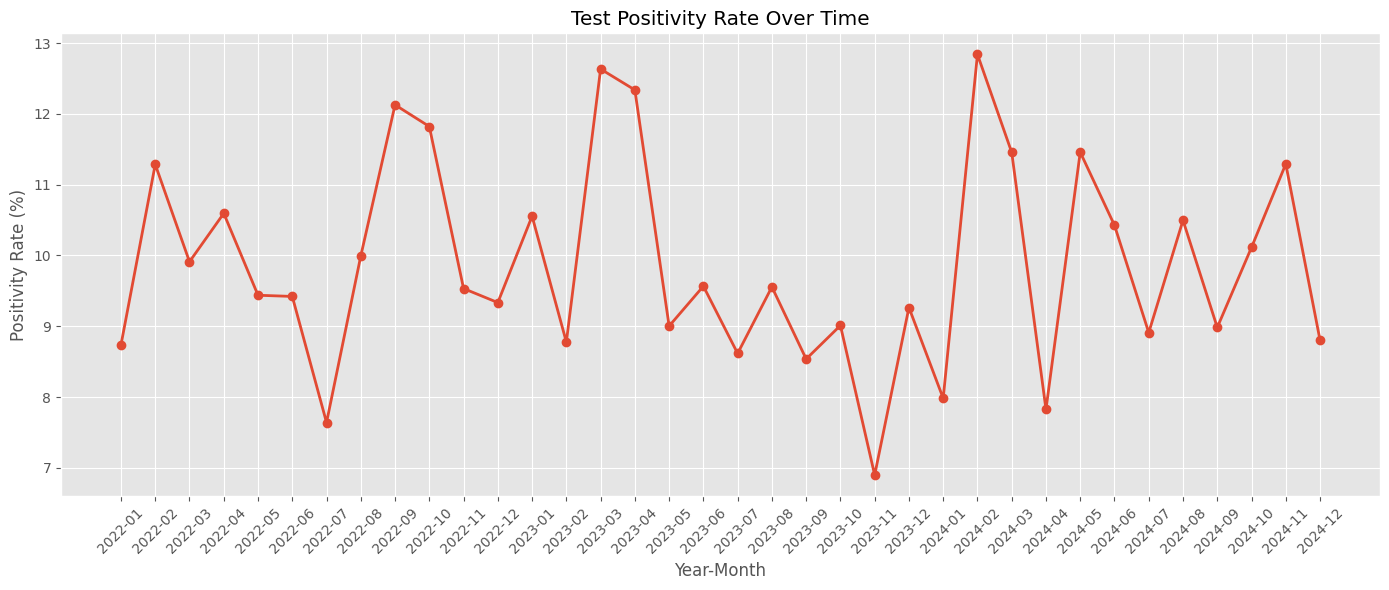

In [15]:
# Visualization: Positivity Rate Trend
plt.figure(figsize=(14, 6))

plt.plot(
    monthly_rate.index,
    monthly_rate["Positivity_Rate"],
    marker="o",
    linewidth=2
)

plt.title("Test Positivity Rate Over Time")
plt.xlabel("Year-Month")
plt.ylabel("Positivity Rate (%)")
plt.xticks(rotation=45)
plt.grid(True)
plt.tight_layout()
plt.show()

In [16]:
# 3. Testing Volume vs Reported Cases
merged = fact_lab_healthcare.merge(
    fact_disease_surveillance,
    on=["date_id", "state_id"],
    how="inner"
)
print(merged.head())

   fact_id_x  date_id  state_id  total_tests  positive_tests  positivity_rate  \
0          1        1         1      22918.0          4084.0            17.82   
1          1        1         1      22918.0          4084.0            17.82   
2          1        1         1      22918.0          4084.0            17.82   
3          1        1         1      22918.0          4084.0            17.82   
4          1        1         1      22918.0          4084.0            17.82   

   vaccination_coverage_pct  booster_coverage_pct  hospital_beds  doctors  \
0                      76.8                  51.4        12451.0     1793   
1                      76.8                  51.4        12451.0     1793   
2                      76.8                  51.4        12451.0     1793   
3                      76.8                  51.4        12451.0     1793   
4                      76.8                  51.4        12451.0     1793   

   ...  recovered_cases  deaths  urban_cases  rura

In [17]:
comparison = (
    merged
    .groupby("date_id")
    .agg(
        Total_Tests=("total_tests", "sum"),
        Reported_Cases=("total_reported_cases", "sum")
    )
)
print(comparison.head())

         Total_Tests  Reported_Cases
date_id                             
1         13058940.0          389653
2         12716664.0          401273
3         13708524.0          311167
4         11645508.0          314071
5         13924848.0          351854


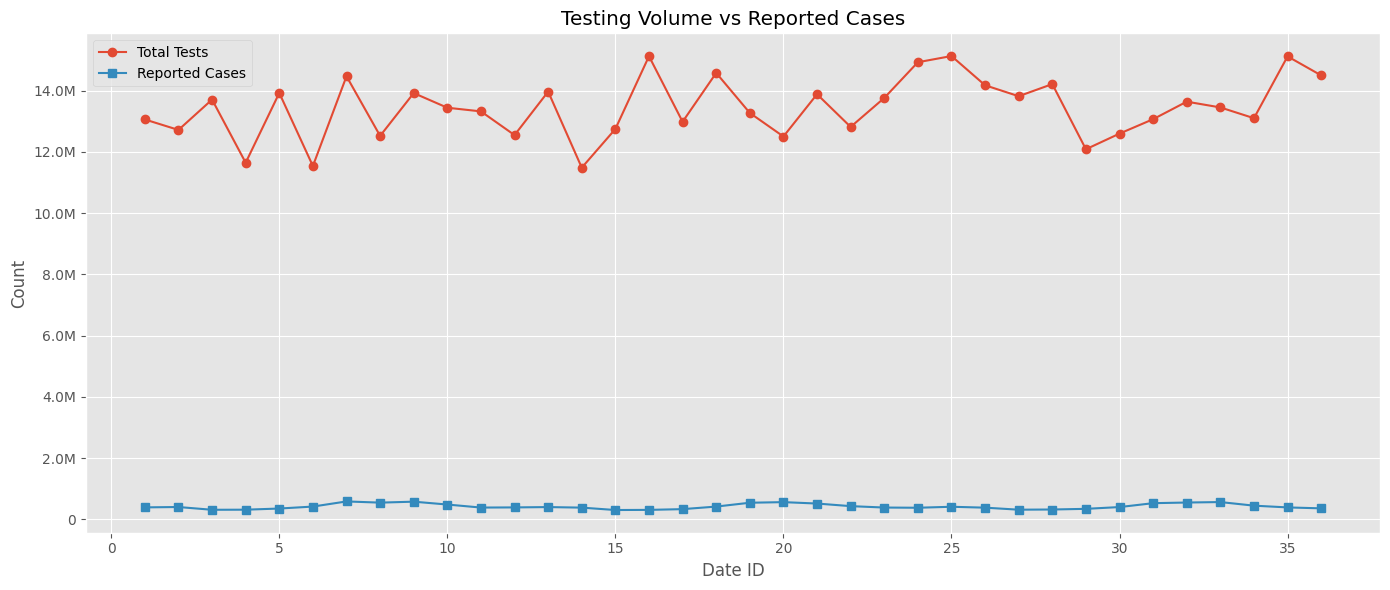

In [18]:
plt.figure(figsize=(14, 6))

plt.plot(
    comparison.index,
    comparison["Total_Tests"],
    marker="o",
    label="Total Tests"
)
plt.plot(
    comparison.index,
    comparison["Reported_Cases"],
    marker="s",
    label="Reported Cases"
)
plt.title("Testing Volume vs Reported Cases")
plt.xlabel("Date ID")
plt.ylabel("Count")
plt.legend()
plt.grid(True)

# Format Y-axis as K / M
plt.gca().yaxis.set_major_formatter(
    FuncFormatter(format_units)
)
plt.tight_layout()
plt.show()

In [19]:
# Correlation between tests and reported cases
correlation = merged["total_tests"].corr(
    merged["total_reported_cases"]
)
print(
    f"Correlation between Tests and Reported Cases: {correlation:.3f}"
)

Correlation between Tests and Reported Cases: 0.689
